<a href="https://colab.research.google.com/github/SkyFlowTraveler/CaliforniaHousingPrice-regression/blob/main/CaliforniaHousesPriceRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
housing = pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [ ]:
housing['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [ ]:
def find_correlation(housing_numeric):
  corr_matrix = housing_numeric.corr()
  return corr_matrix['median_house_value'].sort_values(ascending=False)

housing_numeric = housing.drop('ocean_proximity', axis = 1)

cor_coef = find_correlation(housing_numeric)
print('Correlation Coefficient:', cor_coef)

Correlation Coefficient: median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


<Axes: xlabel='median_income', ylabel='median_house_value'>

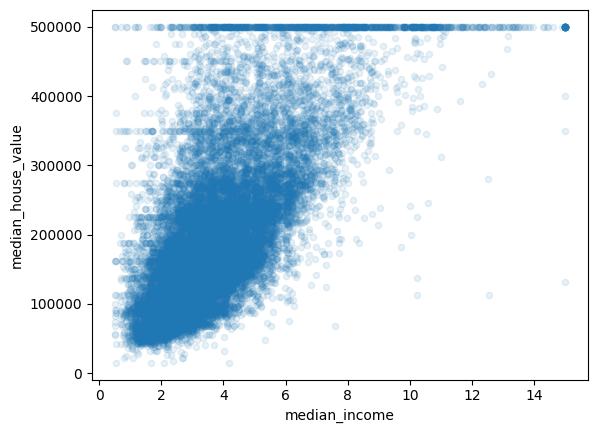

In [ ]:
housing.plot(kind = 'scatter', x = 'median_income', y = 'median_house_value', alpha = 0.1)

array([[<Axes: title={'center': 'median_income'}>]], dtype=object)

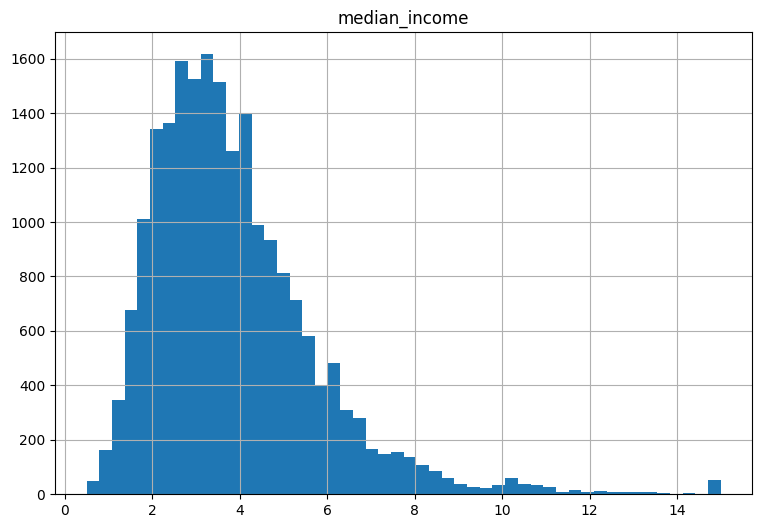

In [ ]:
housing.hist(column='median_income',bins = 50, figsize = (9,6))

<Axes: >

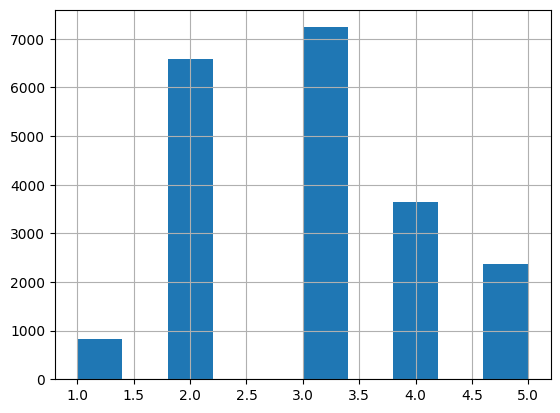

In [ ]:
import numpy as np

housing['income_cat'] = pd.cut(housing['median_income'],
                               bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels = [1,2,3,4,5])
housing['income_cat'].hist()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

def fetch_housing_data():
  return pd.read_csv('https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv')

def set_income_category(housing_selected):
  housing_selected['income_cat']= pd.cut(housing_selected['median_income'],
                                         bins = [0., 1.5, 3.0, 4.5, 6., np.inf],
                                         labels = [1, 2, 3, 4, 5])
  return housing_selected

def get_strat_train_test_dataset(housing_selected):

  split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
  housing_split = split.split(housing_selected, housing_selected['income_cat'])

  #print('housing_split:', housing_split)

  for train_index, test_index in housing_split:
    train_set = housing_selected.loc[train_index]
    test_set = housing_selected.loc[test_index]

  #print('train and test sets:', train_set, test_set)

  for set_ in (train_set, test_set):
    set_.drop('income_cat', axis = 1, inplace = True)

  return train_set, test_set

def sprt_train_and_label_set(train_set):
  housing_tr = train_set.drop('median_house_value', axis = 1)
  housing_labels = train_set['median_house_value'].copy()

  return housing_tr, housing_labels

def get_rmse(housing_labels, predicted_data):

  mse = mean_squared_error(housing_labels, predicted_data)
  rmse = np.sqrt(mse)

  return mse, rmse

def scaler(train):
  if not isinstance(train, pd.DataFrame):
    train = train.to_frame()

  scaler = StandardScaler().fit(train)
  scaled_train = scaler.transform(train)

  scaled_train_df = pd.DataFrame(scaled_train, columns = train.columns, index = train.index)
  return scaled_train_df

housing = fetch_housing_data()

housing_selected = housing[['median_income', 'median_house_value']].copy()

housing_selected = set_income_category(housing_selected)
print(housing_selected)
train_set, test_set = get_strat_train_test_dataset(housing_selected)

housing_tr, housing_labels = sprt_train_and_label_set(train_set)

housing_test, housing_test_labels = sprt_train_and_label_set(test_set)

#print(housing_tr)

#housing_tr = scaler(housing_tr)
#housing_labels = scaler(housing_labels)

#print(housing_tr)

       median_income  median_house_value income_cat
0             8.3252            452600.0          5
1             8.3014            358500.0          5
2             7.2574            352100.0          5
3             5.6431            341300.0          4
4             3.8462            342200.0          3
...              ...                 ...        ...
20635         1.5603             78100.0          2
20636         2.5568             77100.0          2
20637         1.7000             92300.0          2
20638         1.8672             84700.0          2
20639         2.3886             89400.0          2

[20640 rows x 3 columns]


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
lin_reg = Ridge(alpha = 5)
lin_reg.fit(housing_tr, housing_labels)

sample_data = housing_test.iloc[:5]
sample_labels = housing_test_labels.iloc[:5]

predicted_data = lin_reg.predict(sample_data)
print('Predicted Price:', predicted_data)
print('Actual Price:', list(sample_labels))

Predicted Price: [390867.00171714 254330.67157565 228206.10554925 181753.6224119
 226912.39700801]
Actual Price: [500001.0, 162500.0, 204600.0, 159700.0, 184000.0]


In [ ]:
predicted_data = lin_reg.predict(housing_test)
lin_rmse = get_rmse(housing_test_labels, predicted_data)
print('RMSE:', lin_rmse)

RMSE: (6794877624.949066, np.float64(82431.04770017827))


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(housing_test_labels, predicted_data)

print('R^2:', r2)

R^2: 0.4786465630059876


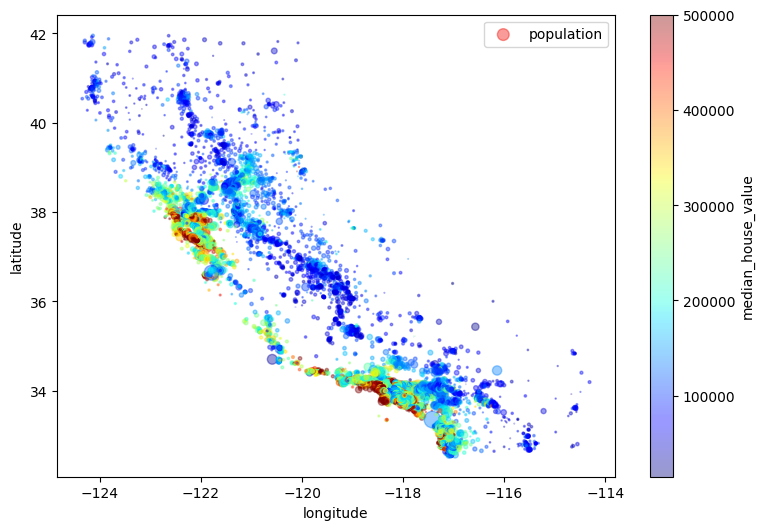

In [ ]:
import matplotlib.pyplot as plt

housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', alpha = 0.4,
             s = housing['population']/250, label = 'population', figsize = (9,6),
             c = 'median_house_value', cmap = plt.get_cmap('jet'), colorbar = True)
plt.legend()

In [ ]:
from sklearn.impute import SimpleImputer

housing_num = housing.drop('ocean_proximity', axis = 1)

imputer = SimpleImputer(strategy = 'median')
imputer.fit(housing_num)
housing_imputer = imputer.transform(housing_num)
print('Imputer return data type:', type(housing_imputer))

housing_new = pd.DataFrame(
    housing_imputer, columns = housing_num.columns, index = housing_num.index)
print('New Housing Dataset:')
print(housing_new.info())

Imputer return data type: <class 'numpy.ndarray'>
New Housing Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def transformation_pipeline():

  num_pipeline = Pipeline([('imputer', SimpleImputer(strategy = 'median')),
                           ('std_scaler', StandardScaler())
                           ])
  return num_pipeline

housing = fetch_housing_data()

housing = set_income_category(housing)

train_set, test_set = get_strat_train_test_dataset(housing)
housing_tr, housing_labels = sprt_train_and_label_set(train_set)
housing_test, housing_test_labels = sprt_train_and_label_set(test_set)

housing_train_num = housing_tr.drop('ocean_proximity', axis = 1)
housing_test_num = housing_test.drop('ocean_proximity', axis = 1)

num_pipeline = transformation_pipeline()
housing_num_tr = num_pipeline.fit_transform(housing_train_num)
housing_num_tst = num_pipeline.fit_transform(housing_test_num)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

lin_reg = LinearRegression()
lin_reg.fit(housing_num_tr, housing_labels)

predicted_data = lin_reg.predict(housing_num_tst)

lin_rmse = get_rmse(housing_test_labels, predicted_data)
r2_error = r2_score(housing_test_labels, predicted_data)

print('RMSE:', lin_rmse)
print('R^2:', r2_error)

RMSE: (4685195365.3129425, np.float64(68448.48694684889))
R^2: 0.6405170421722453


In [ ]:
housing[['ocean_proximity']].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing_tr[['ocean_proximity']]

cat_encoder = OneHotEncoder()
housing_cat_encoder = cat_encoder.fit_transform(housing_cat)

result = housing_cat_encoder.toarray()

print('Data:')
print(result)
category_list = cat_encoder.categories_
print('Categort List::', category_list)

Data:
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Categort List:: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(housing_num_tr)
cat_attribs = ['ocean_proximity']


full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing_tr)
housing_test_prepared = full_pipeline.fit_transform(housing_test)

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


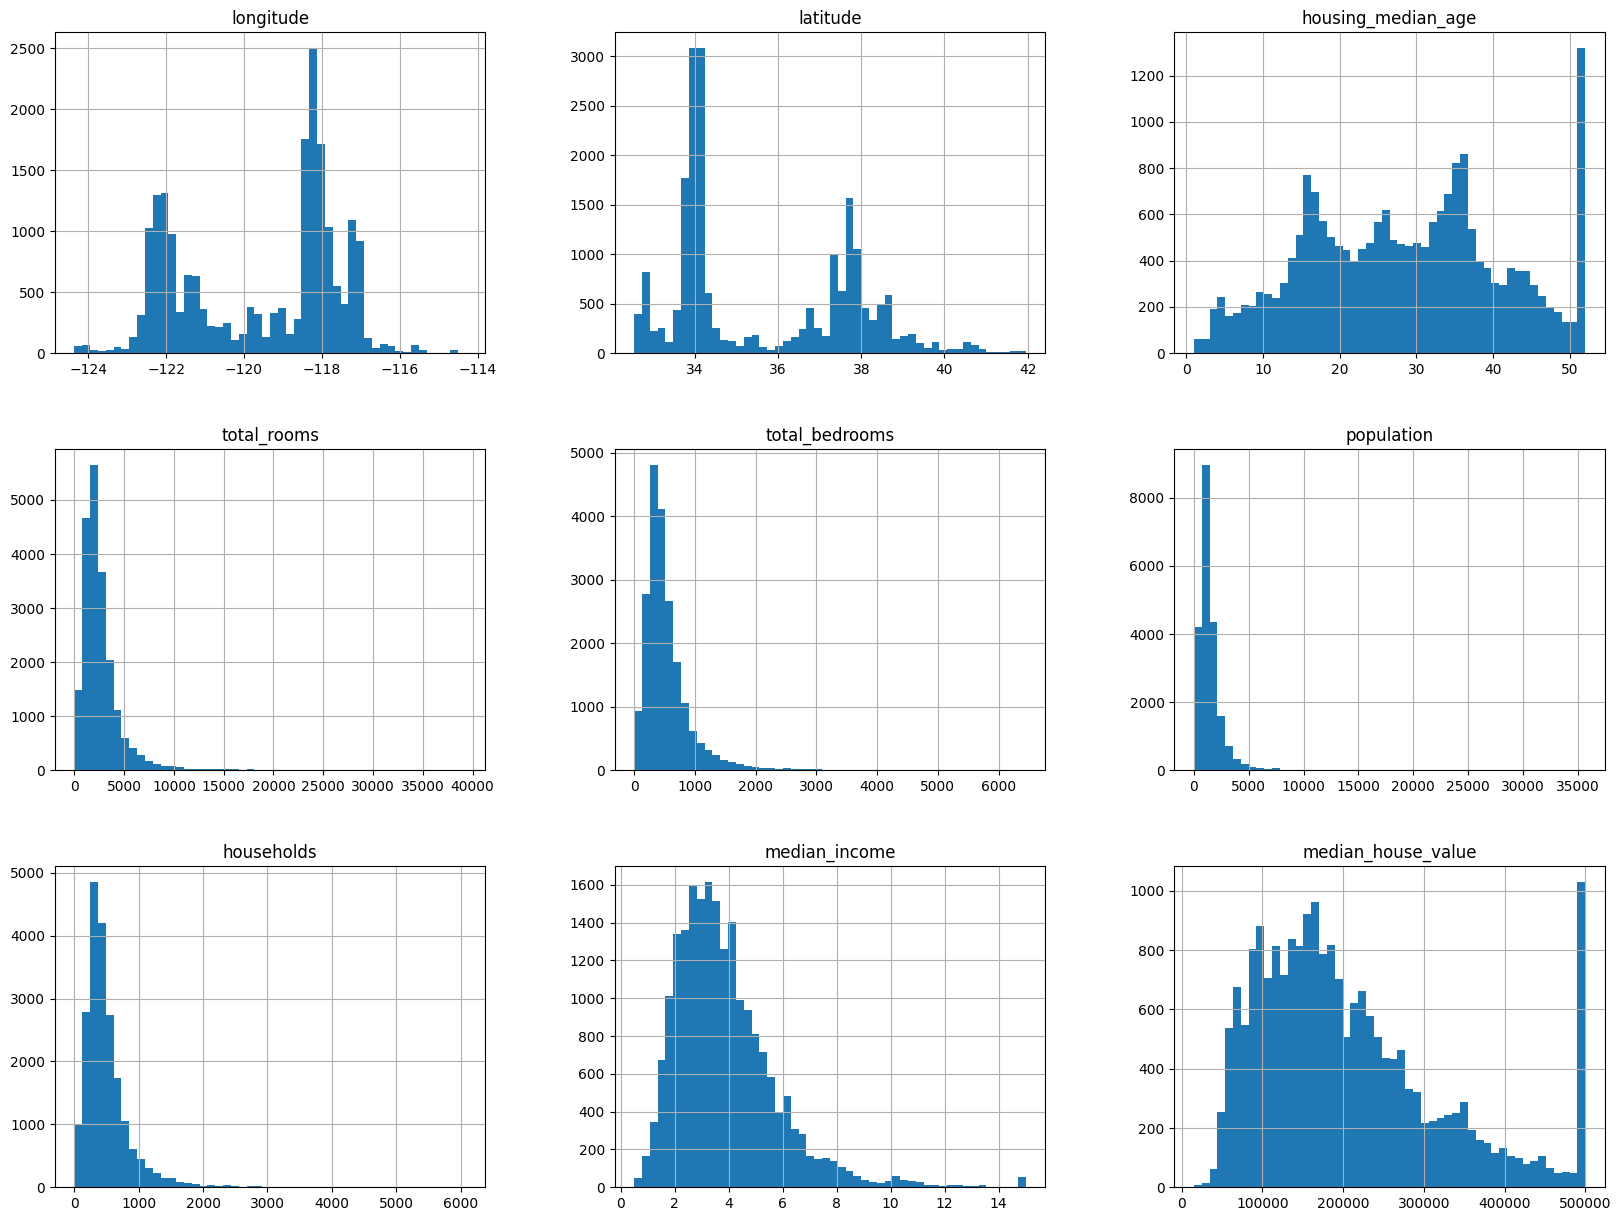

In [ ]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize = (20,15))
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3,4,5,6

class CombinesAttributesAdder(BaseEstimator, TransformerMixin):
  def fit(self, X, y = None):
    return self
  def transform(self, X, y = None):
    rooms_per_household = X[:, rooms_ix]/X[:, households_ix]
    population_per_household = X[:, population_ix]/X[:, households_ix]
    bedrooms_per_room = X[:, bedrooms_ix]/ X[:, rooms_ix]
    return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def transformation_pipeline():

  num_pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy = 'median')),
      ('attribs_adder', CombinesAttributesAdder()),
      ('std_scaler', StandardScaler())
  ])
  return num_pipeline

def complete_pipeline(num_pipeline, num_attribs, cat_attribs):
  full_pipeline = ColumnTransformer([
      ('num', num_pipeline, num_attribs),
      ('cat', OneHotEncoder(), cat_attribs)
  ])
  return full_pipeline

num_pipeline = transformation_pipeline()
num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

full_pipeline = complete_pipeline(num_pipeline, num_attribs, cat_attribs)
housing_prepared = full_pipeline.fit_transform(housing_tr)
housing_test_prepared = full_pipeline.fit_transform(housing_test)

ValueError: A given column is not a column of the dataframe

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

predicted_data = lin_reg.predict(housing_test_prepared)

lin_rmse = get_rmse(housing_labels, predicted_data)
print('RMSE:', lin_rmse)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(min_samples_leaf=17)
tree_reg.fit(housing_prepared, housing_labels)

predicted_data = tree_reg.predict(housing_test_prepared)

tree_rmse = get_rmse(housing_test_labels, predicted_data)
r2_trreg= r2_score(housing_test_labels, predicted_data)

print('RMSE:', tree_rmse)
print('R^2:', r2_trreg)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

predicted_data = forest_reg.predict(housing_test_prepared)

rf_rmse = get_rmse(housing_test_labels, predicted_data)
print('RMSE:', rf_rmse)

In [ ]:
from sklearn.model_selection import cross_val_score

def cross_validation(reg_model, housing_prepared, housing_labels):
  scores = cross_val_score(
      reg_model, housing_prepared,
      housing_labels,
      scoring = 'neg_mean_squared_error', cv = 10)
  rmse_scores = np.sqrt(-scores)
  print('Scores:', rmse_scores)
  print('Mean:', rmse_scores.mean())
  print('StandardDeviation:', rmse_scores.std())

print('DecisionTreeModelCrossVal:')
cross_validation(tree_reg, housing_prepared, housing_labels)
print('LinearRegressionCrossVal:')
cross_validation(lin_reg, housing_prepared, housing_labels)
print('RandomForest RegModelCrossVal:')
cross_validation(forest_reg, housing_prepared, housing_labels)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2,4,6,8]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features':[2,3,4]}
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(
    forest_reg, param_grid, cv = 5,
    scoring = 'neg_mean_squared_error',
    return_train_score = True)
grid_search.fit(housing_prepared, housing_labels)

cvres = grid_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
  print(np.sqrt(-mean_score), params)

In [ ]:
grid_search.best_estimator_

In [ ]:
final_model = grid_search.best_estimator_
print(test_set)
housing_test = test_set.drop('median_house_value', axis = 1)
housing_lbl_test = test_set['median_house_value'].copy()

housing_test_prepared = full_pipeline.transform(housing_test)

final_predictions = final_model.predict(housing_test_prepared)

final_rmse = get_rmse(final_predictions, housing_lbl_test)
print('Test set prediction error', final_rmse)

In [ ]:
'''
models = {
    "SVR": svr_model,
    "OMP": omp_model,
    "KNN": knn_model,
    "Gradient Boosting": gbr_model
}
'''